In [1]:
import os
import random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import torchvision.transforms.functional as TF  # Das fixiert den NameError
import matplotlib.pyplot as plt

# Device Selection (GPU/CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Training auf GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Training auf CPU (Langsam!)")

def read_pfm(file):
    with open(file, "rb") as f:
        header = f.readline().decode('utf-8').rstrip()
        if header == 'PF':
            color = True
        elif header == 'Pf':
            color = False
        else:
            raise Exception('Keine PFM Datei.')

        dims = f.readline().decode('utf-8').split()
        width = int(dims[0])
        height = int(dims[1])

        scale = float(f.readline().decode('utf-8').rstrip())
        # Negativer Scale bedeutet Little Endian (Standard bei SceneFlow)
        if scale < 0:
            endian = '<'
            scale = -scale
        else:
            endian = '>'

        data = np.fromfile(f, endian + 'f')
        shape = (height, width, 3) if color else (height, width)

        data = np.reshape(data, shape)
        data = np.flipud(data) # PFM speichert von unten nach oben
        
        # WICHTIG: Inf-Werte abfangen
        data[data == np.inf] = 0
        
        return data.copy()

    return data

Training auf GPU: NVIDIA GeForce RTX 3080 Ti


In [2]:
class StereoDataset(torch.utils.data.Dataset):
    def __init__(self, left_dir, right_dir, disp_dir, training=True, use_crop=True, use_augmentation=True):
        self.left_paths = sorted([os.path.join(left_dir, f) for f in os.listdir(left_dir) if f.endswith('.png')])
        self.right_paths = sorted([os.path.join(right_dir, f) for f in os.listdir(right_dir) if f.endswith('.png')])
        self.disp_paths = sorted([os.path.join(disp_dir, f) for f in os.listdir(disp_dir) if f.endswith('.pfm')])
        
        self.training = training
        self.use_crop = use_crop
        self.use_augmentation = use_augmentation # <-- NEU: Steuert Helligkeits-Augmentierung
        
        self.to_tensor = transforms.ToTensor()
        self.MAX_DISP_TARGET = 192.0
        self.CROP_SIZE = (240, 320)
        self.debug_print_done = False

    def __len__(self):
        return len(self.left_paths)

    def augment(self, left, right, disp):
        # Führt die Helligkeitsänderung nur durch, wenn aktiv
        if random.random() > 0.2:
            brightness_l = random.uniform(0.95, 1.05)
            brightness_r = random.uniform(0.95, 1.05)
            left = TF.adjust_brightness(left, brightness_l)
            right = TF.adjust_brightness(right, brightness_r)
        return left, right, disp

    def __getitem__(self, idx):
        # 1. Bilder laden & Resizing auf 640x480
        left_img = Image.open(self.left_paths[idx]).convert('L')
        right_img = Image.open(self.right_paths[idx]).convert('L')
        left_img = left_img.resize((640, 480), Image.BILINEAR)
        right_img = right_img.resize((640, 480), Image.BILINEAR)
        
        # 2. PFM Disparität laden & skalieren
        disp_np = read_pfm(self.disp_paths[idx])
        disp_np = np.abs(disp_np)
        disp_np[~np.isfinite(disp_np)] = 0
        
        scale_factor = 640.0 / disp_np.shape[1]
        disp = torch.from_numpy(disp_np.copy()).float().unsqueeze(0)
        disp = disp * scale_factor
        disp = F.interpolate(disp.unsqueeze(0), size=(480, 640), mode='nearest').squeeze(0)
        disp = torch.clamp(disp, 0, self.MAX_DISP_TARGET)

        # 3. In Tensoren wandeln
        left_t = self.to_tensor(left_img)
        right_t = self.to_tensor(right_img)

        # 4. TRAININGSLOGIK: AUGMENTATION & CROP
        if self.training:
            # Augmentierung nur, wenn Flag gesetzt
            if self.use_augmentation:
                left_t, right_t, disp = self.augment(left_t, right_t, disp)
            
            # Cropping nur, wenn Flag gesetzt
            if self.use_crop:
                i, j, h, w = transforms.RandomCrop.get_params(left_t, output_size=self.CROP_SIZE)
                left_t = TF.crop(left_t, i, j, h, w)
                right_t = TF.crop(right_t, i, j, h, w)
                disp = TF.crop(disp, i, j, h, w)

        # Debugging Info beim ersten Sample
        #if not self.debug_print_done:
        #    aug_str = "AKTIV" if (self.training and self.use_augmentation) else "AUS"
        #    crop_str = "CROP" if (self.training and self.use_crop) else "FULL-RES"
        #    print(f"DEBUG: Dataset im Modus {crop_str} | Augmentation: {aug_str}")
        #    self.debug_print_done = True

        return left_t, right_t, disp

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================================
# 1. HAILO-FRIENDLY RESIDUAL BLOCK (Keep as is, excellent for NPU)
# ============================================================================
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)

# ============================================================================
# 2. NPU-OPTIMIZED REFINEMENT (Replacing the heavy Hourglass)
# ============================================================================
class RefinementHead(nn.Module):
    """
    Hierarchical 2D Refinement. 
    Hailo-8 Status: NATIVE (Only 2D Convs, no bottleneck/memory lag)
    """
    def __init__(self, in_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(32, 1, 3, padding=1)
        )

    def forward(self, low_disp, high_res_feat):
        # Resize low-res disparity to high-res target
        up_disp = F.interpolate(low_disp, size=high_res_feat.shape[2:], mode='bilinear', align_corners=False)
        # Cat disparity with features (e.g. Image or intermediate features)
        x = torch.cat([up_disp, high_res_feat], dim=1)
        # Predict residual correction
        return up_disp + self.conv(x)

# ============================================================================
# 3. COST VOLUME (Kept for Geometry Stability)
# ============================================================================
class CostVolumeStridedConv(nn.Module):
    def __init__(self, in_channels, cv_shifts, num_groups):
        super().__init__()
        self.cv_shifts, self.num_groups, self.in_channels = cv_shifts, num_groups, in_channels
        self.shift_conv = nn.Conv2d(in_channels, in_channels * cv_shifts, (1, cv_shifts), groups=in_channels, bias=False)
        self._init_shift_weights()
        self.shift_conv.weight.requires_grad = False
    def _init_shift_weights(self):
        with torch.no_grad():
            self.shift_conv.weight.zero_()
            for c in range(self.in_channels):
                for d in range(self.cv_shifts):
                    self.shift_conv.weight[c * self.cv_shifts + d, 0, 0, self.cv_shifts - 1 - d] = 1.0
    def forward(self, feat_l, feat_r):
        B, C, H, W = feat_l.shape
        feat_r_shifted = self.shift_conv(F.pad(feat_r, (self.cv_shifts - 1, 0, 0, 0), mode='replicate'))
        feat_r_shifted = feat_r_shifted.view(B, C, self.cv_shifts, H, W)
        diff = torch.abs(feat_l.unsqueeze(2) - feat_r_shifted).view(B, self.num_groups, C // self.num_groups, self.cv_shifts, H, W)
        cost = diff.mean(dim=2)
        return cost.reshape(B, self.num_groups * self.cv_shifts, H, W)

# ============================================================================
# 4. FINAL NPU-OPTIMIZED CORE MODEL
# ============================================================================
class StereoNet_NPU_Core(nn.Module):
    def __init__(self, max_disp=192, num_groups=4):
        super().__init__()
        self.max_disp = max_disp
        self.cv_shifts = (max_disp // 4) + 1 # CV on 1/4 resolution
        
        # 1. Feature Extractor (Shared)
        self.init_conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1, bias=False), # 1/2
            nn.BatchNorm2d(32), nn.ReLU(inplace=True)
        )
        self.layer_1_4 = ResBlock(32, 32, stride=2) # 1/4
        
        # 2. Cost Volume & Aggregator (1/4 scale)
        self.cost_volume = CostVolumeStridedConv(32, self.cv_shifts, num_groups)
        self.aggregator = nn.Sequential(
            nn.Conv2d(num_groups * self.cv_shifts, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, self.cv_shifts, 3, padding=1)
        )

        # 3. Refinement Heads (Replacing Hourglass)
        self.refine_v1 = RefinementHead(1 + 32) # Scale 1/2 (Disp + 1/2 Features)
        self.refine_v2 = RefinementHead(1 + 1)  # Scale 1/1 (Disp + Image)

        # 4. OCC-Head
        self.register_buffer("disp_range", torch.arange(0, self.cv_shifts).view(1, -1, 1, 1).float())
        self.occ_head = nn.Sequential(
            nn.Conv2d(2, 16, 3, padding=1), # Input: Gray-Image + Disp-Map
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 1, 3, padding=1) # Output: Occlusion-Logits
        )

    def core(self, left, right, training=True, epoch=0):
        # 1. Feature Extraction
        f_l_1_2 = self.init_conv(left)       # 1/2 Auflösung
        f_l_1_4 = self.layer_1_4(f_l_1_2)    # 1/4 Auflösung
        f_r_1_4 = self.layer_1_4(self.init_conv(right))
        
        # 2. 1/4 Disparity Calculation (Soft-Argmax)
        cv = self.cost_volume(f_l_1_4, f_r_1_4)
        cost_scores = self.aggregator(cv)
        prob = F.softmax(-cost_scores, dim=1)
        disp_4 = torch.sum(prob * self.disp_range, dim=1, keepdim=True)
        
        # 3. Scale up to 1/2 and Refine
        # Wir interpolieren auf die Größe der f_l_1_2 Features
        # Wichtig: * 2.0, weil die Auflösung verdoppelt wurde
        disp_low = F.interpolate(disp_4, size=f_l_1_2.shape[2:], mode='bilinear', align_corners=False) * 2.0
        disp_v1 = self.refine_v1(disp_low, f_l_1_2)
        
        # 4. Scale up to 1/1 and Refine
        # Wir interpolieren auf die Originalgröße (left.shape)
        # Wichtig: * 2.0, weil wir von 1/2 auf 1/1 gehen
        disp_v1_up = F.interpolate(disp_v1, size=left.shape[2:], mode='bilinear', align_corners=False) * 2.0
        disp_final = self.refine_v2(disp_v1_up, left)
        
        # 5. Alles für den Loss auf volle Auflösung bringen
        # Falls disp_low noch auf 1/2 ist, hier für den Loss hochziehen
        disp_low_up = F.interpolate(disp_low, size=left.shape[2:], mode='bilinear', align_corners=False) * 2.0
        
        # Occlusion Dummy (muss gleiche Größe wie disp_final haben)
        # 1. Normalisiere die Inputs für den Head (hilft bei der GradNorm)
        norm_img = left # ist bereits [0, 1]
        norm_disp = disp_final / self.max_disp

        # 2. Head berechnen
        occ_in = torch.cat([norm_img, norm_disp], dim=1)
        occ = self.occ_head(occ_in)
        
        # WICHTIG: Da disp_range auf 1/4 Skala basiert (0-48), 
        # haben wir durch die zwei *2.0 Schritte oben bereits die Zielskala (0-192) erreicht!
        # Wir geben die Tensoren jetzt alle in 1/1 Auflösung zurück.
        return disp_final, disp_v1_up, disp_low_up, occ

    def forward(self, left, right, training=False, epoch=0):
        return self.core(left, right, training=training, epoch=epoch)

# ============================================================================
# 5. ALL-MODE WRAPPER (LR + RL Pass)
# ============================================================================
class StereoFusionAllMode(nn.Module):
    def __init__(self, max_disp=192):
        super().__init__()
        self.core = StereoNet_NPU_Core(max_disp=max_disp)

    def forward(self, left, right, mode="fast", epoch=0):
        training_needed = (mode != "fast")
        out_LR = self.core(left, right, training=training_needed, epoch=epoch)
        if mode == "fast": return {"LR": out_LR}
        
        # RL Pass (Flip Symmetry)
        out_RL_f = self.core(torch.flip(right, [3]), torch.flip(left, [3]), training=training_needed, epoch=epoch)
        out_RL = tuple(torch.flip(t, [3]) for t in out_RL_f)
        return {"LR": out_LR, "RL": out_RL}

In [4]:
@torch.no_grad()
def validate(model, val_loader, device):
    model.eval()
    val_loss = 0
    total_epe = 0
    count = 0

    # Fortschrittsbalken für die Validierung
    val_pbar = tqdm(val_loader, desc="🔍 Validierung", leave=False)
    
    with torch.no_grad():
        for left, right, gt in val_pbar:
            left, right, gt = left.to(device), right.to(device), gt.to(device)
            
            mask = gt > 0
            if not mask.any():
                continue

            # Modus "fast" reicht hier völlig aus, da wir nur die LR-Disparität brauchen
            # Das spart ca. 50% Zeit in der Validierung
            outputs = model(left, right, mode="fast")
        
            # Fokus auf finaler LR-Disparität (Subpixel-Resultat)
            # WICHTIG: outputs["LR"] ist jetzt (pred_final, pred_v1, pred_low, occ)
            # Wir validieren gegen den ersten Index [0]
            pred_LR = outputs["LR"][0] 
            pred_LR = torch.clamp(pred_LR, min=0.0)

            # Metriken berechnen
            # L1 Loss als Proxy für die Qualität
            loss = F.l1_loss(pred_LR[mask], gt[mask])
            # EPE (End Point Error) ist der Standard-Maßstab für Stereo-Matching
            epe = torch.abs(pred_LR[mask] - gt[mask]).mean()

            val_loss += loss.item()
            total_epe += epe.item()
            count += 1

            # Anzeige im Balken
            val_pbar.set_postfix({'val_epe': f"{epe.item():.2f}px"})

        avg_loss = val_loss / count if count > 0 else 0
        avg_epe = total_epe / count if count > 0 else 0
        print
    return avg_loss, avg_epe


In [5]:
import torch.nn.functional as F

import torch.nn.functional as F

def warp(right_img, disp, grid_x=None, grid_y=None):
    """
    Args:
        grid_x, grid_y: Pre-computed grids (optional, für Hailo-Inferenz)
    """
    B, C, H, W = right_img.size()
    
    if grid_x is None or grid_y is None:
        # Training: Erstelle Grids dynamisch
        grid_x, grid_y = torch.meshgrid(
            torch.arange(W, device=right_img.device),
            torch.arange(H, device=right_img.device),
            indexing='xy'
        )
        grid_x = grid_x.unsqueeze(0).expand(B, -1, -1).float()
        grid_y = grid_y.unsqueeze(0).expand(B, -1, -1).float()
    else:
        # Inferenz: Nutze übergebene Grids
        grid_x = grid_x.unsqueeze(0).expand(B, -1, -1)
        grid_y = grid_y.unsqueeze(0).expand(B, -1, -1)

    shifted_x = grid_x - disp.squeeze(1)
    
    # ============ NEU: Subpixel-Toleranz ============
    valid_mask = (shifted_x >= -0.5) & (shifted_x < W - 0.5)
    # ===============================================

    norm_x = 2.0 * shifted_x / (W - 1) - 1.0
    norm_y = 2.0 * grid_y / (H - 1) - 1.0

    vgrid = torch.stack((norm_x, norm_y), dim=3)

    # ============ NEU: Hailo-kompatibles Padding ============
    warped = F.grid_sample(
        right_img, vgrid,
        mode='bilinear',
        padding_mode='border',  # ← Geändert von 'zeros'
        align_corners=False      # ← Geändert von True
    )
    # =======================================================

    return warped, valid_mask.unsqueeze(1).float()


def edge_aware_smoothness_loss(pred_disp, left_img, beta=15.0):
    """
    Beta=15 schützt Kanten radikal. Nur in sehr flachen Bereichen (Gefälle < 1/15)
    wird geglättet. Das verhindert das 'Verwaschen' deiner Stuhlbeine.
    """
    def grad_x(img): return torch.abs(img[:, :, :, :-1] - img[:, :, :, 1:])
    def grad_y(img): return torch.abs(img[:, :, :-1, :] - img[:, :, 1:, :])

    disp_grad_x = grad_x(pred_disp)
    disp_grad_y = grad_y(pred_disp)

    # Graustufen-Gradienten des Referenzbildes
    img_grad_x = grad_x(left_img)
    img_grad_y = grad_y(left_img)

    weight_x = torch.exp(-img_grad_x * beta)
    weight_y = torch.exp(-img_grad_y * beta)

    return (disp_grad_x * weight_x).mean() + (disp_grad_y * weight_y).mean()


def stereo_loss_all_in(outputs_dict, gt, left_img, right_img, 
                       alpha_smooth=0.0, warp_factor=0.0, 
                       lrc_factor=0.0, occ_factor=0.0, rl_geom_factor=0.0):

    # 1. ENTPACKEN
    (pred_final_LR, pred_v1_LR, pred_low_LR, occ_LR) = outputs_dict["LR"]
    mask = gt > 0
    if not mask.any(): 
        return torch.tensor(0.0, device=gt.device, requires_grad=True), {}

    # 2. DATA LOSS (GT-Anker)
    def wl1(p, t, m):
        if p.shape != t.shape: 
            p = F.interpolate(p, size=t.shape[2:], mode='bilinear', align_corners=False)
        return F.smooth_l1_loss(p[m], t[m])

    data_LR = 1.0 * wl1(pred_final_LR, gt, mask) + 0.5 * wl1(pred_v1_LR, gt, mask)

    # 3. PHOTOMETRIC & SMOOTHNESS
    warped_L, valid_L = warp(right_img, pred_final_LR)
    photo_error_map = torch.abs(warped_L - left_img)
    photo_L = (photo_error_map * valid_L).sum() / (valid_L.sum() + 1e-6)
    
    smooth_L = edge_aware_smoothness_loss(pred_final_LR, left_img, beta=15.0)

    # Initialisierung für RL-Pass Variablen
    lrc_loss = torch.tensor(0.0, device=gt.device)
    data_RL = torch.tensor(0.0, device=gt.device)
    occ_target = torch.zeros_like(occ_LR)

    # 4. RL-PASS & LRC LOGIK (Hier wurde d_R_at_L definiert)
    if "RL" in outputs_dict:
        (pred_final_RL, pred_v1_RL, pred_low_RL, occ_RL) = outputs_dict["RL"]
        
        # RL-Supervision
        gt_f = torch.flip(gt, dims=[3])
        mask_f = gt_f > 0
        data_RL = wl1(pred_final_RL, gt_f, mask_f)

        # --- LRC GRID LOGIK START ---
        B, C, H, W = pred_final_LR.shape
        # Erstelle Koordinaten-Grid
        grid_x, grid_y = torch.meshgrid(
            torch.arange(W, device=gt.device), 
            torch.arange(H, device=gt.device), 
            indexing='xy'
        )
        grid_x = grid_x.unsqueeze(0).expand(B, -1, -1).float()
        grid_y = grid_y.unsqueeze(0).expand(B, -1, -1).float()
        
        # Verschiebe Grid nach links um den Betrag der Disparität
        shifted_x = grid_x - pred_final_LR.squeeze(1)
        
        # Normalisierung auf [-1, 1] für grid_sample
        norm_x = 2.0 * shifted_x / (W - 1) - 1.0
        norm_y = 2.0 * grid_y / (H - 1) - 1.0
        vgrid = torch.stack((norm_x, norm_y), dim=3)
        
        # Sample die rechte Vorhersage an den verschobenen Stellen
        d_R_at_L = F.grid_sample(pred_final_RL, vgrid, mode='bilinear', padding_mode='zeros', align_corners=False)
        # --- LRC GRID LOGIK ENDE ---

        lrc_diff = torch.abs(pred_final_LR - d_R_at_L)
        lrc_loss = lrc_diff.mean()

        # ECHO-KILLER LOGIK (Kombination aus Geometrie & Helligkeit)
        # Markiere als Okklusion, wenn LRC widersprüchlich ODER Helligkeit falsch
        occ_target = ((lrc_diff > 1.5) | (photo_error_map > 0.2)).float()

    # 5. OCCLUSION LOSS (Head lernt das Target)
    occ_loss = F.binary_cross_entropy_with_logits(occ_LR, occ_target)

    # 6. TOTAL LOSS BERECHNUNG
    total = (data_LR + 
             rl_geom_factor * data_RL + 
             warp_factor * photo_L + 
             alpha_smooth * smooth_L + 
             lrc_factor * lrc_loss + 
             occ_factor * occ_loss)

    # 7. LOGGING DICTIONARY
    logs = {
        "data_LR": data_LR.item(),
        "data_RL": data_RL.item() if "RL" in outputs_dict else 0.0,
        "photo_L": photo_L.item() * warp_factor,
        "lrc": lrc_loss.item() * lrc_factor,
        "occ": occ_loss.item() * occ_factor
    }
    
    return total, logs




import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm.auto import tqdm
import os
import time

def train_production_all_in(model, train_loader, val_loader, test_dataset, device, 
                            epochs=150, lr=1e-4, start_epoch=0, accumulation_steps=8):
    
    # 1. Start-Setup (Für Phase 1)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Der erste Scheduler plant nur bis zur Hälfte (Epoche 75)
    # Wenn wir bei 0 starten, ist T_max = 75.
    phase1_duration = 75
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=phase1_duration, eta_min=1e-7)
    
    scaler = torch.cuda.amp.GradScaler()

    log_file = "training_log_fresh.txt"
    last_grad_norm = 0.0
    last_damping = 1.0

    print(f"♻️ FRESH START | Ziel: {epochs} Epochen")
    print(f"   Phase 1: Geometrie (0-{phase1_duration})")
    print(f"   Phase 2: All-In + LR Reset (ab {phase1_duration})")
    if start_epoch == 0:
        with open(log_file, "w") as f:
            f.write("epoch\tavg_loss\tval_loss\tval_epe\tdata_LR\tdata_RL\tphoto_L\tlrc\tocc\tlr\talpha_smooth\twarp_factor\tlrc_factor\trl_geom_factor\n")
        print(f"📝 Log-File '{log_file}' neu angelegt (inkl. Header).")

    for epoch in range(start_epoch, epochs):
        model.train()
        
        # --- AUTOMATISCHER LR-RESET BEI EPOCHE 75 ---
        if epoch == 75:
            print(f"\n⚡ TRIGGER: Phase 2 gestartet! Reset LR auf {lr:.1e}")
            
            # 1. LR im Optimizer hart zurücksetzen
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr
            
            # 2. Neuen Scheduler für den Rest (75 bis 150) erstellen
            # T_max ist die verbleibende Zeit
            scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=(epochs - 75), eta_min=1e-6)
            
            # Optional: Damping resetten, damit wir mit voller Kraft starten
            last_damping = 1.0 

        # --- 1. Statik-Reset ---
        epoch_loss = 0.0
        sum_logs = {"data_LR": 0.0, "data_RL": 0.0, "photo_L": 0.0, "lrc": 0.0, "occ": 0.0}
        
        # --- 2. Strategie-Parameter ---
        if epoch < 75:
            # Phase 1: Reine Geometrie (Stabilisierung)
            alpha_smooth = 0.0
            warp_factor = 0.0
            lrc_factor = 0.0
            occ_factor = 0.0
            rl_geom_factor = 0.0
        else:
            # Phase 2: All-In (Fade-In über 10 Epochen)
            # Wir faden von 75 bis 85 ein
            progress = min(1.0, (epoch - 74) / 10.0) 
            
            alpha_smooth = 0.0005 * progress
            warp_factor = 1.5 * progress     # Hoher Druck für Subpixel
            lrc_factor = 0.3 * progress      # Symmetrie
            occ_factor = 0.8 * progress      # Echo-Killer
            rl_geom_factor = 0.5 * progress

        optimizer.zero_grad()
        pbar = tqdm(train_loader, desc=f"Epoche {epoch+1}/{epochs}", ncols=165)
        
        for batch_idx, (left, right, gt) in enumerate(pbar):
            left, right, gt = left.to(device), right.to(device), gt.to(device)
            scheduled_lr = scheduler.get_last_lr()[0]
            
            # Dynamische Akkumulation
            current_accu = accumulation_steps * 2 if last_grad_norm > 800 else accumulation_steps

            with torch.cuda.amp.autocast():
                out_LR = model.core(left, right)
                
                # RL-Pass Logik (nur in Phase 2 aktiv schalten um Rechenzeit in Phase 1 zu sparen?)
                # NEIN: Wir lassen ihn immer mitlaufen, wenn VRAM es erlaubt, oder schalten ihn hart um.
                # Strategie: Um VRAM in Phase 1 zu sparen und BatchSize zu erhöhen, könnte man RL weglassen.
                # Aber für Konsistenz lassen wir die Logik drin, berechnen nur den Loss nicht.
                
                if epoch >= 75:
                    l_f, r_f = torch.flip(left, [3]), torch.flip(right, [3])
                    out_RL_f = model.core(r_f, l_f)
                    out_RL = tuple(torch.flip(t, [3]) for t in out_RL_f)
                    outputs = {"LR": out_LR, "RL": out_RL}
                else:
                    # In Phase 1 sparen wir uns den Backward-Pass für RL, 
                    # aber für VRAM-Konsistenz könnten wir ihn berechnen. 
                    # Hier: Nur LR für Speed in Phase 1.
                    outputs = {"LR": out_LR}
                
                loss, logs = stereo_loss_all_in(outputs, gt, left, right, 
                                                alpha_smooth=alpha_smooth, warp_factor=warp_factor, 
                                                lrc_factor=lrc_factor, occ_factor=occ_factor, 
                                                rl_geom_factor=rl_geom_factor)
                loss_scaled = loss / current_accu

            scaler.scale(loss_scaled).backward()

            if (batch_idx + 1) % current_accu == 0:
                scaler.unscale_(optimizer)
                # In Phase 1 etwas strikteres Clipping, in Phase 2 (Reheat) lockerer
                max_norm_val = 1.0 if epoch < 75 else 2.0
                last_grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm_val).item()
                
                # Damping Logik
                thresh = 500.0
                last_damping = max(0.05, thresh / last_grad_norm) if last_grad_norm > thresh else 1.0
                
                effective_lr = scheduled_lr * last_damping
                for pg in optimizer.param_groups: pg['lr'] = effective_lr
                
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            else:
                effective_lr = scheduled_lr * last_damping

            # Statistik
            epoch_loss += loss.item()
            for k in sum_logs.keys():
                if k in logs:
                    val = logs[k]
                    sum_logs[k] += val.item() if hasattr(val, 'item') else val

            # VRAM & Pbar
            vram_gb = torch.cuda.memory_reserved(device) / 1024**3
            pbar.set_postfix({
                'VRAM': f"{vram_gb:.1f}GB",
                'LR': f"{effective_lr:.1e}",
                'EPE': f"{logs.get('data_LR', 0):.2f}px"
            })

        # --- EPOCH ENDE ---
        val_loss, val_epe = validate(model, val_loader, device)
        scheduler.step()
        
        # Logging
        n_batches = len(train_loader)
        avg_loss = epoch_loss / n_batches
        avg_logs = {k: v / n_batches for k, v in sum_logs.items()}
        
        print(f"📈 Epoche {epoch+1}: Val-EPE: {val_epe:.2f} px")

        with open(log_file, "a") as f:
            f.write(f"{epoch+1}\t{avg_loss:.4f}\t{val_loss:.4f}\t{val_epe:.4f}\t"
                    f"{avg_logs.get('data_LR', 0):.4f}\t{avg_logs.get('data_RL', 0):.4f}\t"
                    f"{avg_logs.get('photo_L', 0):.4f}\t{avg_logs.get('lrc', 0):.4f}\t"
                    f"{avg_logs.get('occ', 0):.4f}\t{scheduled_lr:.2e}\t"
                    f"{alpha_smooth}\t{warp_factor}\t{lrc_factor}\t{rl_geom_factor}\n")

        save_debug_visuals(model, test_dataset, epoch+1, index=6)
        plot_disparity_profile(model, test_dataset, epoch+1, index=6)
        save_preview(model, test_dataset, f"epoch_{(epoch+1):03d}", index=6, warp_func=warp)
        save_symmetry_comparison(model, test_dataset, device, epoch=epoch+1, index=6)
        if (epoch + 1) % 5 == 0:
            torch.save(model.state_dict(), f"StereoFusion_ep_{epoch+1}.pth")

    print("✅ Training beendet.")        




/home/slarc/miniconda3/envs/stereo_wsl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
def save_debug_visuals(model, dataset, epoch, index=0):
    model.eval()

    left, right, gt = dataset[index]
    left  = left.unsqueeze(0).to(device)
    right = right.unsqueeze(0).to(device)

    with torch.no_grad():
        # 1-Pass Forward (wir wollen nur LR)
        out = model(left, right, mode="precise")
        disp_final, disp_v1, disp_low, occ = out["LR"]

    # CPU konvertieren
    disp_final_np = disp_final.squeeze().cpu().numpy()
    disp_v1_np    = disp_v1.squeeze().cpu().numpy()
    disp_low_np   = disp_low.squeeze().cpu().numpy()
    occ_np        = occ.squeeze().cpu().numpy()
    left_np       = left.squeeze().cpu().numpy()
    right_np      = right.squeeze().cpu().numpy()

    # Plotten
    fig, axs = plt.subplots(2, 3, figsize=(14, 8))

    axs[0,0].imshow(left_np, cmap="gray")
    axs[0,0].set_title("Left Image")

    axs[0,1].imshow(right_np, cmap="gray")
    axs[0,1].set_title("Right Image")

    axs[0,2].imshow(disp_low_np, cmap="inferno")
    axs[0,2].set_title("Disp Low")

    axs[1,0].imshow(disp_v1_np, cmap="inferno")
    axs[1,0].set_title("Disp v1")

    axs[1,1].imshow(disp_final_np, cmap="inferno")
    axs[1,1].set_title("Disp Final")

    axs[1,2].imshow(occ_np, cmap="gray")
    axs[1,2].set_title("Occlusion Map")

    for ax in axs.flat:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(f"training_progress/StereoFusion_debug_epoch_{epoch:03d}.png")
    plt.close()

    
import matplotlib.pyplot as plt

def save_preview(model, dataset, name, index=6, warp_func=None):
    model.eval()
    with torch.no_grad():
        # 1. Daten holen
        left, right, gt = dataset[index]
        left_cuda = left.unsqueeze(0).to(device)
        right_cuda = right.unsqueeze(0).to(device)

        # 2. Precise Mode (LR und RL berechnen)
        outputs = model(left_cuda, right_cuda, mode="precise")
        
        # Tensoren extrahieren (finaler Output ist Index 0)
        disp_LR = outputs["LR"][0].cpu().squeeze()
        disp_RL = outputs["RL"][0].cpu().squeeze()
        
        # 3. Echo-Analyse (LRC-Map)
        # Wir berechnen die Differenz. Wo es hell leuchtet, sind Echos oder Okklusionen.
        echo_map = torch.abs(disp_LR - disp_RL)

        # 4. Plotting
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle(f"Debug Analysis: {name} (Left Edge Echo Check)", fontsize=16)

        # Zeile 1
        axes[0, 0].imshow(left.permute(1, 2, 0).numpy())
        axes[0, 0].set_title("Input Left")
        
        axes[0, 1].imshow(gt.squeeze(), cmap='jet', vmin=0, vmax=192)
        axes[0, 1].set_title("Ground Truth")
        
        im_lr = axes[0, 2].imshow(disp_LR, cmap='jet', vmin=0, vmax=192)
        axes[0, 2].set_title("Prediction LR (Standard)")
        fig.colorbar(im_lr, ax=axes[0, 2])

        # Zeile 2
        im_rl = axes[1, 0].imshow(disp_RL, cmap='jet', vmin=0, vmax=192)
        axes[1, 0].set_title("Prediction RL (Flip-Symmetry)")
        fig.colorbar(im_rl, ax=axes[1, 0])

        # Die Echo-Map zeigt uns das Problem am linken Rand
        im_echo = axes[1, 1].imshow(echo_map, cmap='hot', vmin=0, vmax=20)
        axes[1, 1].set_title("Echo Analysis (LRC-Diff)")
        fig.colorbar(im_echo, ax=axes[1, 1])

        # Fused Output (einfacher Durchschnitt zur Visualisierung)
        fused = (disp_LR + disp_RL) / 2
        axes[1, 2].imshow(fused, cmap='jet', vmin=0, vmax=192)
        axes[1, 2].set_title("Fused Result (Draft)")

        for ax in axes.flatten():
            ax.axis('off')

        plt.tight_layout()
        plt.savefig(f"training_progress/StereoFusion_analysis_{name}.png", bbox_inches='tight')
        plt.close()
        print(f"📸 Analyse-Plot gespeichert: {name}_analysis.png")


def plot_disparity_profile(model, dataset, epoch, index=0):
    model.eval()

    # --- Load sample ---
    left, right, gt = dataset[index]
    left  = left.unsqueeze(0).to(device)
    right = right.unsqueeze(0).to(device)
    gt    = gt.unsqueeze(0).to(device)

    with torch.no_grad():
        # Wir nutzen "precise", um alle Daten (inkl. Occlusion) zu bekommen
        out = model(left, right, mode="precise")
        # Entpacken der LR-Resultate
        disp_final, disp_v1, disp_low, occ_pred = out["LR"]

    # Convert to numpy
    left_np  = left.squeeze().cpu().numpy()
    gt_np    = gt.squeeze().cpu().numpy()
    low_np   = disp_low.squeeze().cpu().numpy()
    v1_np    = disp_v1.squeeze().cpu().numpy()
    final_np = disp_final.squeeze().cpu().numpy()
    
    # Occlusion Map: Sicherstellen, dass sie 2D ist (H, W)
    if occ_pred.dim() == 4: # [B, C, H, W]
        occ_np = occ_pred.squeeze(0).squeeze(0).cpu().numpy()
    else:
        occ_np = occ_pred.squeeze().cpu().numpy()

    H, W = final_np.shape

    # Three profile rows
    rows = [
        int(H * 0.25),
        int(H * 0.50),
        int(H * 0.75)
    ]
    row_labels = ["25% height", "50% height", "75% height"]

    # ---------------------------------------------------------
    # Create a single figure with 4 subplots
    # ---------------------------------------------------------
    # Agg-Backend nutzen (verhindert oft Probleme in Headless-Umgebungen/Notebooks)
    fig, axs = plt.subplots(4, 1, figsize=(14, 20)) 

    # --- Panel 1: Left image with profile lines ---
    axs[0].imshow(left_np, cmap="gray")
    for r in rows:
        axs[0].axhline(r, color="yellow", linewidth=1.5)
    axs[0].set_title(f"Profile Positions – Epoch {epoch}")
    axs[0].axis("off")

    # --- Panels 2–4: One profile per line ---
    for ax, r, label in zip(axs[1:], rows, row_labels):
        # 1. Okklusions-Overlay (Hintergrund)
        ax.fill_between(range(W), 0, 192, where=(occ_np[r, :] > 0.5), 
                        color='red', alpha=0.15, label="Pred. Occlusion (Mask)")

        # 2. Die Disparitäts-Linien
        ax.plot(gt_np[r, :],    color="black",  label="GT (Ground Truth)", linewidth=2.5)
        ax.plot(low_np[r, :],   color="orange", label="disp_low (CostVolume)", alpha=0.6, linestyle='--')
        ax.plot(v1_np[r, :],    color="green",  label="disp_v1 (Refine d=4)", alpha=0.7)
        ax.plot(final_np[r, :], color="red",    label="disp_final (V2 + Photo + LRC)", linewidth=2)

        ax.set_title(
            f"Disparity Profile at {label} (Row {r})\n"
            "Red Shading: Model detected Occlusion/Invalid area"
        )
        ax.set_xlabel("Pixel (X)")
        ax.set_ylabel("Disparity")
        ax.set_ylim(-5, 200) 
        ax.grid(True, which='both', linestyle='--', alpha=0.5)
        ax.legend(loc='upper right', fontsize='small', ncol=2)

    plt.tight_layout()
    
    # Ordner erstellen falls nicht vorhanden
    os.makedirs("training_progress", exist_ok=True)
    
    # Abspeichern
    plt.savefig(f"training_progress/StereoFusion_profile_epoch_{epoch:03d}.png")
    
    # WICHTIG: Speicher freigeben und Anzeige unterdrücken
    plt.close(fig)

def save_symmetry_comparison(model, dataset, device, epoch=0, index=0, save_path=None):
    """
    Erzeugt einen detaillierten Symmetrie-Vergleich ohne Notebook-Output.
    Spalte 1: Normaler Durchlauf (LR)
    Spalte 2: Symmetrischer Durchlauf (RL) - Rohdaten vor dem Back-Flip
    """
    model.eval()
    
    # 1. Daten vorbereiten
    left, right, gt = dataset[index]
    left_t = left.unsqueeze(0).to(device)
    right_t = right.unsqueeze(0).to(device)
    
    with torch.no_grad():
        # LR Pass
        pred_lr, _, _, occ_lr = model.core(left_t, right_t)
        
        # RL Pass (Flipped Inputs)
        left_f = torch.flip(left_t, [3])
        right_f = torch.flip(right_t, [3])
        pred_rl_raw, _, _, occ_rl_raw = model.core(right_f, left_f)
        
        # LRC Differenz berechnen (für die "leuchtenden Zonen")
        # Wir flippen pred_rl_raw zurück, um es mit pred_lr zu vergleichen
        pred_rl_backflipped = torch.flip(pred_rl_raw, [3])
        lrc_diff = torch.abs(pred_lr - pred_rl_backflipped)

    # Hilfsfunktion für Numpy-Konvertierung
    def n(t): return t.squeeze().cpu().numpy()

    # 2. Plotting (8 Panels für maximale Einsicht)
    fig, axes = plt.subplots(4, 2, figsize=(14, 18))
    plt.subplots_adjust(wspace=0.1, hspace=0.3)

    # ZEILE 1: WAS DAS MODELL SIEHT (Inputs)
    axes[0, 0].imshow(n(left_t), cmap='gray')
    axes[0, 0].set_title("Input Links (Original)")
    axes[0, 1].imshow(n(right_f), cmap='gray')
    axes[0, 1].set_title("Input Rechts (Geflippt)")

    # ZEILE 2: VORHERSAGEN (Geometrie)
    vmax = 192 # Skalierung für 640er Breite
    axes[1, 0].imshow(n(pred_lr), cmap='magma', vmin=0, vmax=vmax)
    axes[1, 0].set_title("Prediction LR")
    axes[1, 1].imshow(n(pred_rl_raw), cmap='magma', vmin=0, vmax=vmax)
    axes[1, 1].set_title("Prediction RL (Roh / Geflippt)")

    # ZEILE 3: FEHLER-ANALYSE (LRC & OCC)
    # Hier siehst du die Echos leuchten
    axes[2, 0].imshow(n(lrc_diff), cmap='hot', vmin=0, vmax=20)
    axes[2, 0].set_title("LRC-Differenz (Widerspruch)")
    axes[2, 1].imshow(n(torch.sigmoid(occ_lr)), cmap='gray', vmin=0, vmax=1)
    axes[2, 1].set_title("Occlusion Map (LR Pass)")

    # ZEILE 4: GROUND TRUTH
    axes[3, 0].imshow(n(gt), cmap='magma', vmin=0, vmax=vmax)
    axes[3, 0].set_title("GT Original")
    axes[3, 1].imshow(n(torch.flip(gt.unsqueeze(0), [3])), cmap='magma', vmin=0, vmax=vmax)
    axes[3, 1].set_title("GT Geflippt")

    for ax in axes.ravel():
        ax.axis('off')

    plt.suptitle(f"Symmetrie-Diagnose Epoche {epoch} | Index {index}", fontsize=18)
    
    file_name = save_path or f"symmetry_diag_ep{epoch:03d}_idx{index}.png"
    plt.savefig(file_name, bbox_inches='tight', dpi=150)
    plt.close(fig) # Verhindert Anzeige im Notebook
    print(f"✅ Symmetrie-Debug gespeichert unter: {file_name}")


--- Sanity Check: Index 0 ---
✓ Erfolgreich geladen in 0.0442 Sekunden
✓ Shape Left: torch.Size([1, 240, 320])
✓ Shape Disp: torch.Size([1, 240, 320])
✓ Max Disparität: 51.19 Pixel
✓ Durchschnittliche Tiefe: 12.43 Pixel
✅ Skalierung korrekt: Bereich 0 bis 51.19 Pixel.


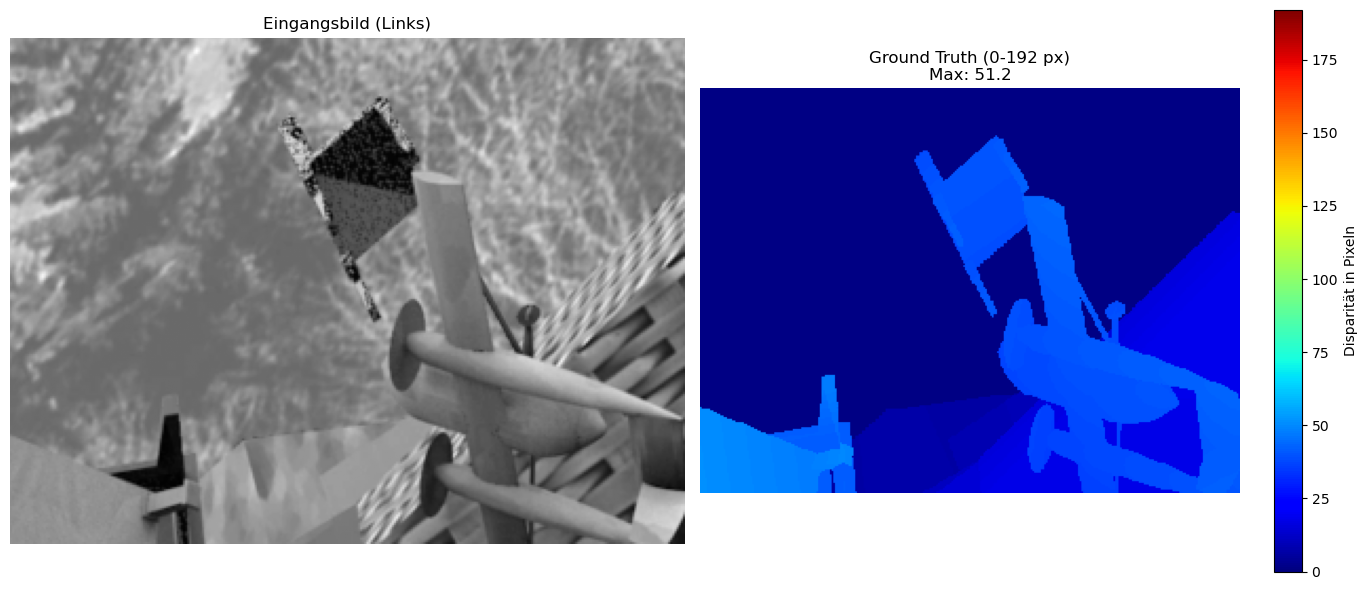

In [7]:
import time
import matplotlib.pyplot as plt

def check_dataset_sanity(dataset, index=0):
    print(f"--- Sanity Check: Index {index} ---")
    start_time = time.time()
    
    try:
        left, right, disp = dataset[index]
        load_time = time.time() - start_time
        
        # Statistiken berechnen
        max_val = disp.max().item()
        mean_val = disp.mean().item()
        
        print(f"✓ Erfolgreich geladen in {load_time:.4f} Sekunden")
        print(f"✓ Shape Left: {left.shape}")
        print(f"✓ Shape Disp: {disp.shape}")
        print(f"✓ Max Disparität: {max_val:.2f} Pixel")
        print(f"✓ Durchschnittliche Tiefe: {mean_val:.2f} Pixel")

        # Validierung der Skalierung
        if max_val <= 1.01:
            print("⚠️ WARNUNG: Die Disparität ist noch auf 0-1 normiert!")
            print("   Stelle sicher, dass Zelle 2 'return left, right, disp_final' (0-192) ausgibt.")
        elif max_val > 192.1:
            print(f"⚠️ WARNUNG: Max Disp ({max_val:.2f}) überschreitet das Limit von 192!")
        else:
            print(f"✅ Skalierung korrekt: Bereich 0 bis {max_val:.2f} Pixel.")

        # Visualisierung
        fig, ax = plt.subplots(1, 2, figsize=(14, 6))
        
        # Eingangsbild
        img_display = left.permute(1, 2, 0).numpy()
        ax[0].imshow(img_display, cmap='gray')
        ax[0].set_title("Eingangsbild (Links)")
        ax[0].axis('off')
        
        # Disparität (Wichtig: vmin/vmax auf den neuen Bereich 0-192)
        im = ax[1].imshow(disp.squeeze().numpy(), cmap='jet', vmin=0, vmax=192)
        ax[1].set_title(f"Ground Truth (0-192 px)\nMax: {max_val:.1f}")
        ax[1].axis('off')
        
        # Farbbalken hinzufügen für besseres Verständnis
        plt.colorbar(im, ax=ax[1], label="Disparität in Pixeln")
        
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"❌ FEHLER beim Laden von Index {index}:")
        import traceback
        traceback.print_exc()

# Aufruf
# check_dataset_sanity(dataset, index=0)
dataset = StereoDataset(
    left_dir='/home/slarc/datasets/sceneflow/left', 
    right_dir='/home/slarc/datasets/sceneflow/right', 
    disp_dir='/home/slarc/datasets/sceneflow/disp'
)

check_dataset_sanity(dataset, index=0)

In [ ]:
def main():
    # 1. GPU Vorbereitung
    torch.cuda.empty_cache()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Pfade definieren
    left_dir = '/home/slarc/datasets/sceneflow/left'
    right_dir = '/home/slarc/datasets/sceneflow/right'
    disp_dir = '/home/slarc/datasets/sceneflow/disp'
    
    # ------------------------------------------------------------
    # 2. Dataset Setup (Wichtig für den Reheat!)
    # ------------------------------------------------------------
    # Hier setzen wir use_crop=False und use_augmentation=False für Phase 2 Start
    full_data_train = StereoDataset(
        left_dir, right_dir, disp_dir, 
        training=True, 
        use_crop=False,           # Volle 640x480
        use_augmentation=False    # Saubere Daten für den Reheat
    )
    
    full_data_val = StereoDataset(
        left_dir, right_dir, disp_dir, 
        training=False, 
        use_crop=False, 
        use_augmentation=False
    )

    # Indizes für konsistenten Split berechnen
    dataset_size = len(full_data_train)
    train_size = int(0.9 * dataset_size)
    
    # Fixer Seed sorgt dafür, dass Train/Val-Split immer gleich bleibt
    indices = torch.randperm(dataset_size, generator=torch.Generator().manual_seed(42)).tolist()
    train_indices = indices[:train_size]
    val_indices   = indices[train_size:]

    train_dataset = torch.utils.data.Subset(full_data_train, train_indices)
    val_dataset   = torch.utils.data.Subset(full_data_val, val_indices)

    # ------------------------------------------------------------
    # 3. DataLoaders (VRAM-optimiert für RTX 3080 Ti)
    # ------------------------------------------------------------
    last_epoch = 0 # Wir starten nach Epoche 75 neu
    
    # Bei 640x480 und aktivem RL-Pass (Phase 2) ist BS=2 der sicherste Weg
    current_bs = 8 
    current_accu = 6  # BS 2 * Accu 24 = 48 effektive Bilder pro Update
        
    train_loader = DataLoader(
        train_dataset,
        batch_size=current_bs,
        shuffle=True,
        num_workers=8,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=2
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=1, # Validierung immer einzeln
        shuffle=False,
        num_workers=4,
        pin_memory=False
    )

    # Test-Dataset für die visuellen Previews während des Trainings
    test_dataset = StereoDataset(
        left_dir=left_dir,
        right_dir=right_dir,
        disp_dir=disp_dir,
        training=False,
        use_crop=False
    )

    # ------------------------------------------------------------
    # 4. Modell & BatchNorm
    # ------------------------------------------------------------
    model = StereoFusionAllMode(max_disp=192).to(device)

    def set_bn_momentum(model, momentum=0.01):
        for m in model.modules():
            if isinstance(m, torch.nn.BatchNorm2d):
                m.momentum = momentum
        print(f"✅ Alle BatchNorm-Layer auf Momentum {momentum} gesetzt.")

    # ------------------------------------------------------------
    # 5. Checkpoint laden (Nur Gewichte, kein Optimizer-State!)
    # ------------------------------------------------------------
    checkpoint_path = f"StereoFusion_ep_{last_epoch}.pth"

    if os.path.exists(checkpoint_path):
        # Wir laden nur die Gewichte, um mit frischem LR-Fokus (1e-4) zu starten
        model.load_state_dict(torch.load(checkpoint_path), strict=False)
        print(f"✅ Checkpoint {checkpoint_path} geladen. Reheat wird vorbereitet.")
    else:
        print(f"⚠️ Achtung: {checkpoint_path} nicht gefunden! Start bei 0.")
        last_epoch = 0

    # BatchNorm Momentum für stabilere Statistik bei kleinen Batch-Sizes anpassen
    set_bn_momentum(model, momentum=0.01)
    
    # ------------------------------------------------------------
    # 6. Training Start (Phase 2 mit Reheat)
    # ------------------------------------------------------------
    print(f"🚀 Starte Reheat ab Epoche {last_epoch+1}")
    print(f"   Modus: Full-Res (640x480) | BS: {current_bs} | Accu: {current_accu}")
    
    train_production_all_in(
        model,
        device=device,
        train_loader=train_loader,
        val_loader=val_loader,
        test_dataset=test_dataset,
        epochs=150,             # Ziel: 150 Epochen
        lr=1.0e-4,              # Voller Reheat Power
        start_epoch=last_epoch, # 75
        accumulation_steps=current_accu
    )

if __name__ == '__main__':
    main()




/tmp/ipykernel_936727/1842606838.py:183: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


⚠️ Achtung: StereoFusion_ep_0.pth nicht gefunden! Start bei 0.
✅ Alle BatchNorm-Layer auf Momentum 0.01 gesetzt.
🚀 Starte Reheat ab Epoche 1
   Modus: Full-Res (640x480) | BS: 8 | Accu: 6
♻️ FRESH START | Ziel: 150 Epochen
   Phase 1: Geometrie (0-75)
   Phase 2: All-In + LR Reset (ab 75)
📝 Log-File 'training_log_fresh.txt' neu angelegt (inkl. Header).


Epoche 1/150:   0%|                                                                                                                         | 0/2933 [00:00<?, ?it/s]/tmp/ipykernel_936727/1842606838.py:248: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoche 1/150: 100%|█████████████████████████████████████████████████████████████████████████| 2933/2933 [06:35<00:00,  7.41it/s, VRAM=4.2GB, LR=1.0e-04, EPE=14.50px]
                                                                                                        

📈 Epoche 1: Val-EPE: 8.05 px
📸 Analyse-Plot gespeichert: epoch_001_analysis.png
✅ Symmetrie-Debug gespeichert unter: symmetry_diag_ep001_idx6.png


Epoche 2/150: 100%|██████████████████████████████████████████████████████████████████████████| 2933/2933 [06:33<00:00,  7.45it/s, VRAM=4.2GB, LR=1.0e-04, EPE=4.12px]
                                                                                                        

...

Epoche 74/150: 100%|█████████████████████████████████████████████████████████████████████████| 2933/2933 [06:26<00:00,  7.58it/s, VRAM=4.2GB, LR=2.8e-07, EPE=2.44px]
                                                                                                        

📈 Epoche 74: Val-EPE: 3.86 px
📸 Analyse-Plot gespeichert: epoch_074_analysis.png
✅ Symmetrie-Debug gespeichert unter: symmetry_diag_ep074_idx6.png


🔍 Validierung:  58%|█████████████████▉             | 1510/2607 [00:21<00:13, 79.93it/s, val_epe=8.56px]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Epoche 78/150: 100%|████████████████████████████████████████████████████████████████████████| 2933/2933 [11:51<00:00,  4.12it/s, VRAM=6.4GB, LR=1.0e-04, EPE=11.29px]
                                                                                                        

📈 Epoche 78: Val-EPE: 4.16 px
📸 Analyse-Plot gespeichert: epoch_078_analysis.png
✅ Symmetrie-Debug gespeichert unter: symmetry_diag_ep078_idx6.png


Epoche 79/150:   5%|███▉                                                                      | 154/2933 [00:38<10:21,  4.47it/s, VRAM=6.4GB, LR=1.0e-04, EPE=5.29px]

In [ ]:
%abort

In [ ]:
import matplotlib.pyplot as plt
full_dataset = StereoDataset(
        left_dir='/home/slarc/datasets/sceneflow/left',
        right_dir='/home/slarc/datasets/sceneflow/right',
        disp_dir='/home/slarc/datasets/sceneflow/disp',
        training=True
    )
val_ratio = 0.1
val_size = int(len(full_dataset) * val_ratio)
train_size = len(full_dataset) - val_size

train_dataset, val_dataset = torch.utils.data.random_split(
        full_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

# Ein Bild aus dem Dataset holen
left, right, gt = train_dataset[7491] 

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(left.squeeze(), cmap='gray')
plt.title("Eingangsbild (Ist es aufrecht?)")

plt.subplot(1, 3, 2)
plt.imshow(gt.squeeze(), cmap='jet')
plt.title("GT Disparität")

# Check: Wo sind die Gradienten am stärksten?
# Wenn dy > dx, dann ist die Disparität vertikal orientiert!
dy, dx = torch.gradient(gt.squeeze())
plt.subplot(1, 3, 3)
plt.imshow(dx.abs() > dy.abs(), cmap='gray')
plt.title("Weiß = Horizontale Struktur\nSchwarz = Vertikale Struktur")
plt.show()

In [ ]:
# Testen Sie:
feat = make_feature_extractor()
dummy = torch.randn(1, 1, 480, 640)
out = feat(dummy)
print(f"Feature channels: {out.shape[1]}")  # Muss 32 sein!

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms
from PIL import Image

# ---------------------------------------------------------
# Hilfsfunktion: Bild laden und normalisieren
# ---------------------------------------------------------
def load_gray_image(path):
    img = Image.open(path).convert("L")
    t = transforms.ToTensor()
    return t(img).unsqueeze(0).cuda()

# Pfade und Device
left_path  = "/home/slarc/datasets/sceneflow/left/0000006.png"
right_path = "/home/slarc/datasets/sceneflow/right/0000006.png"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

left  = load_gray_image(left_path)
right = load_gray_image(right_path)

# Modell laden (Stelle sicher, dass die Klasse definiert ist)
model = StereoFusionAllMode().to(device)
model.eval()

with torch.no_grad():
    # 1. Fast Mode (Nur LR Pass)
    out_fast = model(left, right, mode="fast")
    # Extraktion aus dem Dictionary-Key "LR"
    disp_fast = out_fast["LR"][0]
    occ_fast  = out_fast["LR"][3]

    # 2. Precise Mode (LR und geflippter RL Pass)
    out_prec = model(left, right, mode="precise")
    disp_prec_LR = out_prec["LR"][0]   # Normaler Pass
    disp_prec_RL = out_prec["RL"][0]   # Symmetrischer RL-Pass (bereits zurückgeflippt!)
    
    # Echo-Analyse: Wo unterscheiden sich LR und RL? (Meist am linken Rand)
    echo_map = torch.abs(disp_prec_LR - disp_prec_RL)

# ---------------------------------------------------------
# Visualisierung: Der "Miststück-Check"
# ---------------------------------------------------------
def show_disp(disp, title, subplot_pos, cmap="magma"):
    plt.subplot(2, 2, subplot_pos)
    disp_np = disp.squeeze().cpu().numpy()
    plt.imshow(disp_np, cmap=cmap, vmin=0, vmax=192)
    plt.colorbar(label="Pixel")
    plt.title(title)
    plt.axis("off")

plt.figure(figsize=(16, 10))

# Oben Links: Fast Mode (Standard)
show_disp(disp_fast, "Fast Mode (LR only)", 1)

# Oben Rechts: Precise Mode LR
show_disp(disp_prec_LR, "Precise Mode (LR Pass)", 2)

# Unten Links: Precise Mode RL (Der Retter für den linken Rand)
show_disp(disp_prec_RL, "Precise Mode (RL Pass - Flipped)", 3)

# Unten Rechts: Echo-Analyse (LRC-Diff)
# Hier siehst du die Fehler am linken Rand leuchten!
show_disp(echo_map, "Echo Analysis (LRC Diff)", 4, cmap="hot")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# EPE Check
# ---------------------------------------------------------
# Falls gt_disp.npy nicht existiert, erstellen wir eine Dummy-Maske zum Testen
try:
    gt = np.load("gt_disp.npy")
    gt = torch.tensor(gt, dtype=torch.float32).unsqueeze(0).unsqueeze(0).cuda()
    valid = gt > 0
    
    def calc_epe(pred, gt_val, mask):
        return torch.abs(pred - gt_val)[mask].mean().item()

    epe_fast = calc_epe(disp_fast, gt, valid)
    epe_prec = calc_epe(disp_prec_LR, gt, valid)

    print("-" * 30)
    print(f"EPE Fast Mode   : {epe_fast:.4f} px")
    print(f"EPE Precise Mode: {epe_prec:.4f} px")
    print("-" * 30)
except FileNotFoundError:
    print("GT Datei nicht gefunden. Überspringe EPE Check.")


In [ ]:
import torch
from your_model_file import StereoNetLite_GrabberCore

# 1. Load trained model
model = StereoNetLite_GrabberCore(max_disp=192, num_groups=4, input_size=(480, 640))
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# 2. Create dummy inputs
dummy_left = torch.randn(1, 1, 480, 640)
dummy_right = torch.randn(1, 1, 480, 640)

# 3. Test forward pass
with torch.no_grad():
    output = model(dummy_left, dummy_right, training=False)
    print(f"Output shape: {output.shape}")  # Should be [1, 1, 480, 640]

# 4. Export to ONNX
torch.onnx.export(
    model,
    (dummy_left, dummy_right),
    "stereo_hailo.onnx",
    export_params=True,
    opset_version=11,
    do_constant_folding=True,
    input_names=['left_image', 'right_image'],
    output_names=['disparity'],
    dynamic_axes={
        'left_image': {0: 'batch_size'},
        'right_image': {0: 'batch_size'},
        'disparity': {0: 'batch_size'}
    }
)

print("✅ ONNX export successful: stereo_hailo.onnx")

# 5. Verify ONNX
import onnx
onnx_model = onnx.load("stereo_hailo.onnx")
onnx.checker.check_model(onnx_model)
print("✅ ONNX model is valid")

# 6. Test ONNX inference
import onnxruntime as ort
session = ort.InferenceSession("stereo_hailo.onnx")
onnx_output = session.run(
    None,
    {'left_image': dummy_left.numpy(), 'right_image': dummy_right.numpy()}
)
print(f"✅ ONNX inference successful, output shape: {onnx_output[0].shape}")

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Deine vorhandenen Hilfsfunktionen (PFM & Bilder) ---
def read_pfm(file):
    with open(file, "rb") as f:
        header = f.readline().decode('utf-8').rstrip()
        if header != 'Pf': raise Exception('Keine PFM Pf-Datei.')
        dims = f.readline().decode('utf-8').split()
        width, height = int(dims[0]), int(dims[1])
        scale = float(f.readline().decode('utf-8').rstrip())
        endian = '<' if scale < 0 else '>'
        data = np.fromfile(f, endian + 'f')
        data = np.reshape(data, (height, width))
        data = np.flipud(data)
        data[data == np.inf] = 0
        return data.copy()

# --- 2. Die Analyse-Funktion ---
import torch
import torch.nn.functional as F
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def analyze_checkpoint_pil(checkpoint_path, left_path, right_path, gt_path, row_y=120):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    target_size = (640, 480) # (W, H)
    
    # 1. Modell laden (weights_only=True für Sicherheit)
    model = StereoFusionAllMode().to(device)
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model.eval()

    # 2. Bilder laden & Resizen (Dein Code)
    left_img_pil = Image.open(left_path).convert('L').resize(target_size, Image.BILINEAR)
    right_img_pil = Image.open(right_path).convert('L').resize(target_size, Image.BILINEAR)
    
    # In Tensor umwandeln [1, 1, 480, 640]
    img_l = torch.from_numpy(np.array(left_img_pil)).float().unsqueeze(0).unsqueeze(0).to(device)
    img_r = torch.from_numpy(np.array(right_img_pil)).float().unsqueeze(0).unsqueeze(0).to(device)

    # 3. Ground Truth laden & Resizen
    gt_orig = read_pfm(gt_path) # Nutzt deine Funktion
    orig_h, orig_w = gt_orig.shape
    
    # WICHTIG: Wenn wir das Bild verkleinern, müssen wir die Disparitätswerte skalieren!
    scale_factor = target_size[0] / orig_w
    gt_rescaled = F.interpolate(torch.from_numpy(gt_orig).unsqueeze(0).unsqueeze(0), 
                                size=(target_size[1], target_size[0]), 
                                mode='nearest').squeeze().numpy()
    gt_rescaled = gt_rescaled * scale_factor # Werte an neue Auflösung anpassen

    # 4. Inferenz
    with torch.no_grad():
        outputs = model(img_l, img_r, mode="precise")
        pred_lr = outputs["LR"][0].cpu().squeeze().numpy()

    # 5. Plotten
    plt.figure(figsize=(15, 6))
    x = np.arange(target_size[0])
    
    plt.plot(x, gt_rescaled[row_y, :], color='black', label='GT (PFM, skaliert)', linewidth=2)
    plt.plot(x, pred_lr[row_y, :], color='red', label='Prediction LR', alpha=0.8)
    
    plt.fill_between(x, gt_rescaled[row_y, :], pred_lr[row_y, :], 
                     where=(np.abs(pred_lr[row_y, :] - gt_rescaled[row_y, :]) > 3),
                     color='red', alpha=0.1, label='Fehler > 3px')

    plt.title(f"Profil-Check Zeile {row_y} (Skalierung: {orig_w} -> {target_size[0]})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Aufruf

# ================================================================
# --- 3. DER FUNKTIONSAUFRUF (HIER PASSIERT ES) ---
# ================================================================

if __name__ == "__main__":
    # Pfade anpassen!
    MY_CHECKPOINT = "StereoFusion_5.pth"
    TEST_L = "/home/slarc/datasets/sceneflow/left/0000052.png"
    TEST_R = "/home/slarc/datasets/sceneflow/right/0000052.png"
    TEST_GT = "/home/slarc/datasets/sceneflow/disp/0000052.pfm"

    # Aufruf für die Problem-Zone (Stuhlbein-Echo oben links)
    analyze_checkpoint(
        checkpoint_path=MY_CHECKPOINT,
        left_path=TEST_L,
        right_path=TEST_R,
        gt_path=TEST_GT,
        row_y=120  # Wähle die Zeile, in der das Stuhlbein im Bild sitzt
    )

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import os
path = '/home/slarc/datasets/sceneflow/disp/' # Update this
print(f"Directory exists: {os.path.exists(path)}")
print(f"Files in directory: {os.listdir(path)[:5]}") # Shows first 5 files

# 1. Function Call
# Replace 'path_to_your_file.pfm' with your actual file path
file_path = '/home/slarc/datasets/sceneflow/disp/disparity_0000000.pfm'
try:
    disparity_map = read_pfm(file_path)
    
    # 2. Visualization
    plt.figure(figsize=(12, 6))
    
    # Use 'magma' or 'plasma' for depth/disparity; it's easier on the eyes
    img = plt.imshow(disparity_map, cmap='magma')
    
    plt.title(f"Stereo Ground Truth Disparity\nResolution: {disparity_map.shape[1]}x{disparity_map.shape[0]}")
    plt.colorbar(img, label='Disparity (pixels)')
    plt.axis('off') # Hide axes for a cleaner look
    
    plt.show()

except FileNotFoundError:
    print(f"Error: The file at {file_path} was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

In [ ]:
import os
path = '/mnt/c/temp/sceneflow/disp/' # Update this
print(f"Directory exists: {os.path.exists(path)}")
print(f"Files in directory: {os.listdir(path)[:5]}") # Shows first 5 files